<a href="https://colab.research.google.com/github/sambencoding/Data-Science-Assignments/blob/main/Copy_of_Unit5ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator

# Unit 5 Exercises: Leverage + Practice with GLMs

In these exercises, we'll focus on:
- how to recognize high leverage values, and what to do about them.
- how to decide when a generalized linear model is better than than an all normal, straight line model

We'll start  by looking at the full NBA data set from class, and interogate why I removed so many observations from that data set.

We'll finish with another classic data set, some deemographic data from the Kalahari !Kung San people collected by Nancy Howell in Botswana between August 1967 and May 1969.

##Leverage

Let's take a look at the full basketball data set.

In [5]:
#load the data into a pandas dataframe, and print it
url_basketball = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/basketball2324.csv'
#I could have put the url string directly into pd.read_csv()
basketball = pd.read_csv(url_basketball,dtype={'Pos':'category'})

Before, we put a minutes restriction on what players we looked at, and removed anyone who never missed a free throw.

I've commented out that code, for reference, below. We're going to attempt to run the same analysis without removing any data

In [6]:
#only look at players who played more than 400 minutes
#basketball = basketball.query('MP > 400')
#remove players who never missed a free throw
#basketball = basketball.query('`FT%` != 1.0')

In [7]:
basketball

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Player-additional
0,Precious Achiuwa,PF-C,24,TOT,74,18,1624,235,469,0.501,...,191,296,487,97,46,68,83,143,565,achiupr01
1,Bam Adebayo,C,26,MIA,71,71,2416,530,1017,0.521,...,159,578,737,278,81,66,162,159,1367,adebaba01
2,Ochai Agbaji,SG,23,TOT,78,28,1641,178,433,0.411,...,74,142,216,83,47,44,64,117,455,agbajoc01
3,Santi Aldama,PF,23,MEM,61,35,1618,247,568,0.435,...,72,280,352,138,43,54,69,89,654,aldamsa01
4,Nickeil Alexander-Walker,SG,25,MIN,82,20,1921,236,538,0.439,...,35,132,167,204,64,42,76,143,655,alexani01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,Thaddeus Young,PF,35,TOT,33,6,439,65,108,0.602,...,46,57,103,57,23,5,15,49,137,youngth01
568,Trae Young,PG,25,ATL,54,54,1942,433,1008,0.430,...,23,126,149,583,72,11,235,109,1389,youngtr01
569,Omer Yurtseven,C,25,UTA,48,12,545,99,184,0.538,...,72,136,208,29,8,18,37,52,222,yurtsom01
570,Cody Zeller,C,31,NOP,43,0,320,26,62,0.419,...,48,64,112,39,9,5,16,45,76,zelleco01


**Task1**:

Make a scatter plot with FT% of each player on the horizontal axis and FG% on the vertical axis.

What patterns do you notice? Why do you think they are there?

Text(0, 0.5, 'FG%')

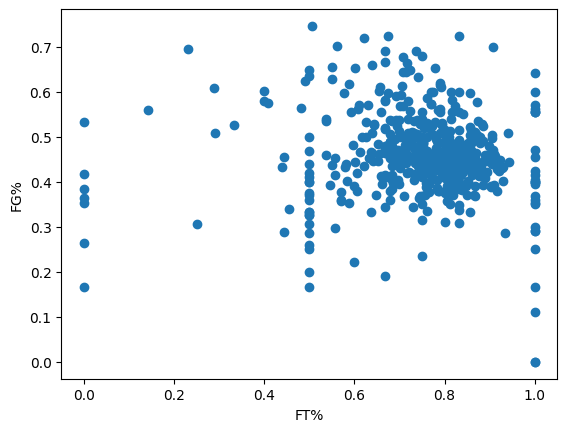

In [8]:
plt.scatter(basketball['FT%'] , basketball['FG%'])
plt.xlabel("FT%")
plt.ylabel("FG%")

Some patterns that i notice here are that 0.0, 0.5, and 1.0 on the FT% have straight lines. Also the people with a 100 percent in the free throw percentage have fewer minutes played than the other, hence leading me to believe that this data does not accuratly represent their performances.

**Task2**:

Make a scatter plot with FT% on the horizontal axis and FG% on the vertical axis. Do this for each each Position in the data set.

Pay special attention to the plots for C and PF.

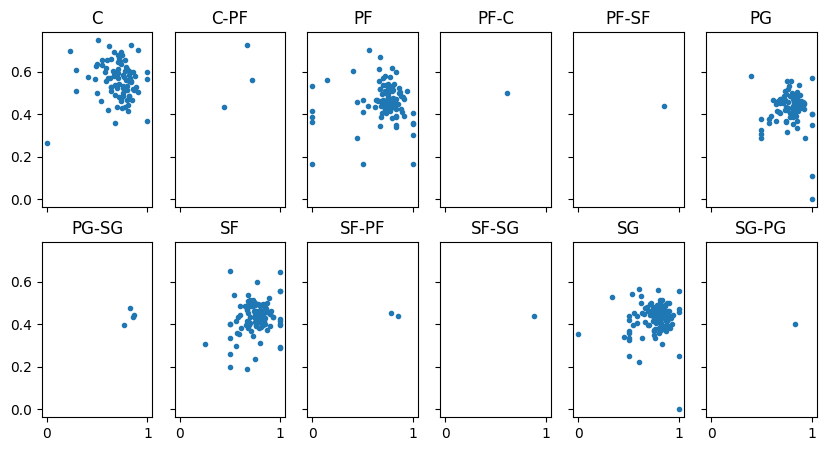

In [13]:
pos_idx = basketball.Pos.cat.codes.values

pos_codes = basketball.Pos.cat.categories

bb_coords = {"pos": pos_codes}

_, ax = plt.subplots(2, 6, figsize=(10, 5), sharex=True, sharey=True)
ax = np.ravel(ax)

for i, p in enumerate(pos_codes):
    ax[i].scatter(
        x = basketball.query('Pos == @p')['FT%'],
        y =  basketball.query('Pos == @p')['FG%'],
        marker=".")
    ax[i].set_title(f"{p}")

**Task3**:

Originally, I was going to get you to create and run an individual linear regression model for each of the positions.

But I couldn't even get model to run.

Explain why a linear regression model won't run on the full dataset. HInt: look at the graphs you made above, and compare and contrast them to the ones from class.

Or: if you do what I could not and get a linear regression model to run on the full data set, I'll give you full credit and a high five.

A linear regression will not work on this full dataset because of the vertical line on the data set on 0.0, 0.5, and 1.0 on the FT% axis. I think for these people they dont have enoughdata to define their free throw percentages because they don't get enough playing time. This leads to have the straight lines at 0.0, 0.5, and 1.0. These data points will most likely mess up the linear model.

## From Linear Model to Generalized Linear Model

You'll now fit a linear regression on the height and weight for people or the Kalahari !Kung San people. Height will be the predictor and weight will be the predicted.

Here's the raw data.

In [10]:
#downloads the data from my github
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [11]:
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


**Task4**:

Make a scatter plot of height versus weight for the howell data set.

Text(0, 0.5, 'weight')

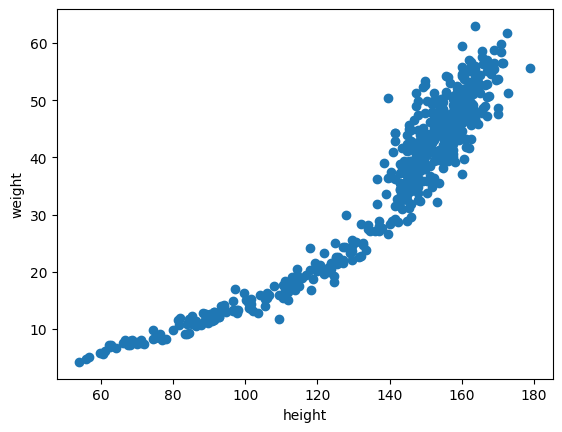

In [14]:
plt.scatter(howell['height'] , howell['weight'])
plt.xlabel("height")
plt.ylabel("weight")

**Task5**:

Create and run a stright line linear regression model on the howell data set with height predicting weight. Visualize your model and its posterior.

In [22]:
with pm.Model() as model_how:
    #mean line priors
    α = pm.Normal("α", mu=0, sigma=3)
    β = pm.Normal("β", mu=0, sigma=10)
    σ = pm.HalfNormal("σ", 1)
    m = pm.Deterministic('m',α + β * howell.height.values)
    #the likelihood
    y = pm.Normal("y_pred",
                  mu=m,
                  sigma=σ,
                  observed=howell['weight'])
    ibm_hdata = pm.sample()

Output()

Output()

Text(0, 0.5, 'weight')

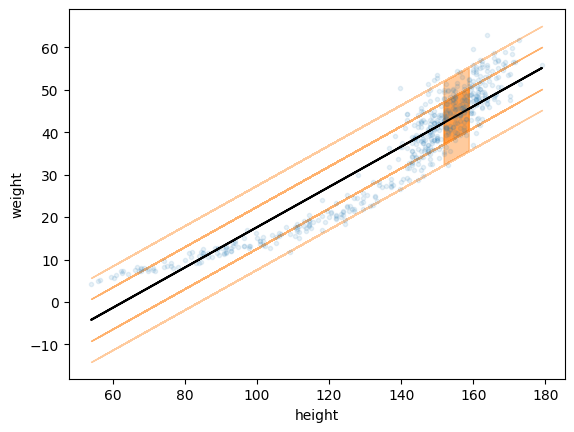

In [32]:
_, ax = plt.subplots()

ax.plot(howell.height, howell.weight, "C0.", alpha=0.1)

posterior_lba = az.extract(idata_how)

μ_m = posterior_lba["m"].mean("sample").values
σ_m = posterior_lba["σ"].mean("sample").values

ax.plot(howell.height, μ_m, c="k")
ax.fill_between(howell.height, μ_m + 1 * σ_m, μ_m - 1 * σ_m, alpha=0.6, color="C1")
ax.fill_between(howell.height, μ_m + 2 * σ_m, μ_m - 2 * σ_m, alpha=0.4, color="C1")

ax.set_xlabel("height")
ax.set_ylabel("weight")

**Task6**:

Run a posterior predictive check for model_howell, plot the posterior predictive distribution, and comment on the fit of the model you made in Task5.

In [30]:
pm.sample_posterior_predictive(
    idata_how, model = model_how, extend_inferencedata=True
    )

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

Text(0, 0.5, 'weight')

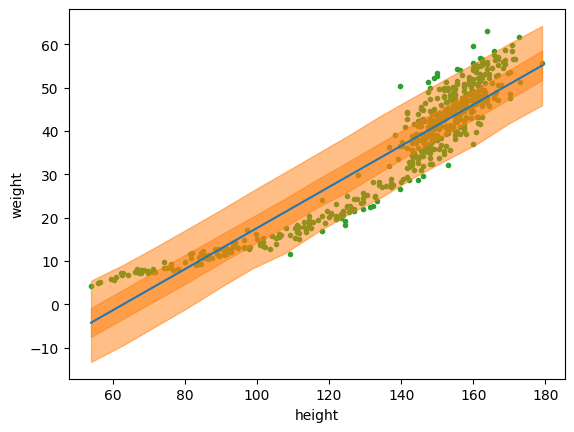

In [33]:
#posterior predictive distribution
#expected line
mean_line = idata_how.posterior["m"].mean(("chain", "draw"))
height = np.random.normal(howell.height.values, 0.01)
idx = np.argsort(height)
x = np.linspace(height.min(), height.max(), 15)
#grabs the HDI, and readied graphing.
y_pred_q = idata_how.posterior_predictive["y_pred"].quantile([0.03, 0.97, 0.25, 0.75], dim=["chain", "draw"])
y_hat_bounds = iter(    [PchipInterpolator(height[idx], y_pred_q[i][idx])(x)  for i in range(4)])
#plots raw data and our line of best fit
_, ax = plt.subplots()
ax.plot(howell.height, howell.weight, "C2.", zorder=-3)
ax.plot(howell.height[idx], mean_line[idx], c="C0")
for lb, ub in zip(y_hat_bounds, y_hat_bounds): ax.fill_between(x, lb, ub, color="C1", alpha=0.5)
#label axes
ax.set_xlabel("height")
ax.set_ylabel("weight")

**Task7**:

Create and visualize the posterior of a generalized linear model that improves the on the fit of the model you made in Task5.

<Axes: ylabel='height'>

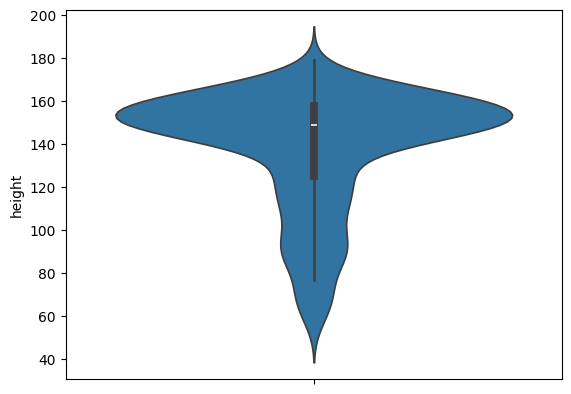

In [34]:
sns.violinplot(howell.height)

In [36]:
with pm.Model() as model_howexp:
    #mean line priors
    α = pm.Normal("α", sigma=10)
    β = pm.Normal("β", sigma=10)
    #mean line
    μ = pm.Deterministic("m", α + β * howell.height)
    #standard deviation
    σ = pm.HalfNormal("σ", sigma = 10)
    #normal likelihood
    y_pred = pm.LogNormal("y_pred", mu=μ, sigma=σ, observed=howell.weight)
    idata_howexp = pm.sample()

Sampling chain 1, 0 divergences ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  10% 0:00:12 / 0:00:01

Text(0, 0.5, 'weight')

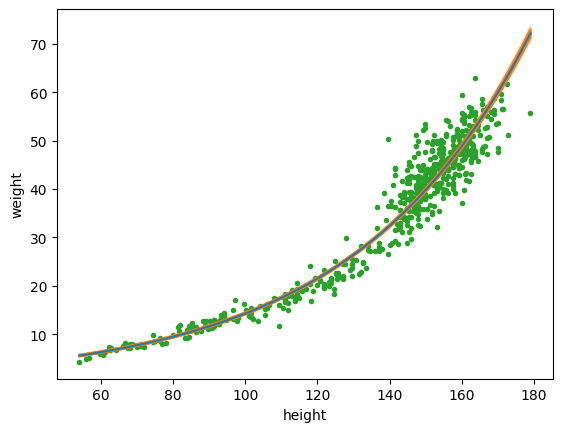

In [37]:
#gets posterior samples
posterior = az.extract(idata_howexp, num_samples=100)
x_plot = xr.DataArray(
    np.linspace(howell.height.min(), howell.height.max(), 50),
    dims="plot_id"
    )
#expected line
mean_line = posterior["α"].mean() + posterior["β"].mean() * x_plot
lines = posterior["α"] + posterior["β"] * x_plot
_, ax = plt.subplots()
ax.plot(x_plot, np.exp(lines.T), c="C1", alpha=0.2, label="lines")
#mean line
ax.plot(x_plot, np.exp(mean_line), c="C0", label="mean line")
ax.plot(howell.height, howell.weight, "C2.", zorder=-3)
#label axes
ax.set_xlabel("height")
ax.set_ylabel("weight")

**Task8**:

Run a posterior predictive check, and visualize the posterior predictive distribution, for the model you made in Task7.

Comment on the fit.

In [38]:
pm.sample_posterior_predictive(
    idata_howexp, model = model_howexp, extend_inferencedata=True
    )

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

Text(0, 0.5, 'weight')

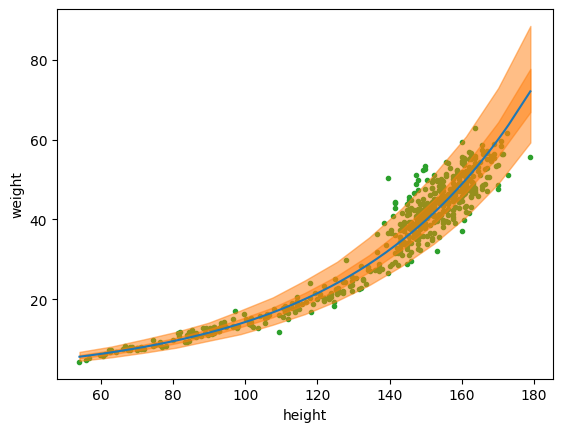

In [40]:
mean_line = idata_howexp.posterior["m"].mean(("chain", "draw"))
heights = np.random.normal(howell.height.values, 0.01)
idx = np.argsort(heights)
x = np.linspace(heights.min(), heights.max(), 15)
y_pred_q = idata_howexp.posterior_predictive["y_pred"].quantile(
    [0.03, 0.97, 0.25, 0.75], dim=["chain", "draw"]
)
y_hat_bounds = iter(
    [
        PchipInterpolator(heights[idx], y_pred_q[i][idx])(x)
        for i in range(4)
    ]
)

_, ax = plt.subplots()
ax.plot(howell.height, howell.weight, "C2.", zorder=-3)
ax.plot(howell.height[idx], np.exp(mean_line[idx]), c="C0")

for lb, ub in zip(y_hat_bounds, y_hat_bounds):
    ax.fill_between(x, lb, ub, color="C1", alpha=0.5)

ax.set_xlabel("height")
ax.set_ylabel("weight")

We can see in the prosterior that this is a good fit. It has a narrowed in the lower parts from 60-80 and widened in the higer parts, from 140-180. This data follows an exponential trend.